In [99]:
import sys
from pathlib import Path
from uncertainties import ufloat
import country_converter as coco
import matplotlib.pyplot as plt
import re
import pandas as pd
import math
import numpy as np
from uncertainties import ufloat, nominal_value, std_dev

# ---------------------------- Run from Repo Root ----------------------------
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

# ---------------------------- File Paths ----------------------------
country_list_csv = BASE_DIR / "data" / "STANDARD_COUNTRY_LIST.csv"
CR_Box_Countries = BASE_DIR / "data" / "CR_Box_Countries_MS.csv"
ecw_country = BASE_DIR / "results" / "ECWbyCountry.csv"
ecw_region = BASE_DIR / "results" / "ECWbyRegion.csv"
Baghouse_Airflow = BASE_DIR /'data'/"BaghouseAirflow.csv"

from country_pkg import Country

In [33]:
# ------------------------ Functions ----------------------------

def generate_countries_from_multiple_csvs(
    country_csv_path,
    cr_box_csv_path=None,
    ecw_csv_path=None,
    baghouse_csv_path=None
):
    # ---------------- Main country CSV ----------------
    df = pd.read_csv(country_csv_path, encoding='cp1252')
    required_cols = ['ISO-3', 'Country Name']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"CSV must have a column named '{col}'")
    
    # ---------------- CR Box CSV ----------------
    cr_box_df = None
    if cr_box_csv_path:
        cr_box_df = pd.read_csv(cr_box_csv_path, encoding='cp1252')
        if "Country" not in cr_box_df.columns:
            raise ValueError("CR Box CSV must have a 'Country' column")
        cr_box_df["Country"] = cr_box_df["Country"].apply(Country._cc.convert, to="name_short")
    
    # ---------------- ECW CSV ----------------
    ecw_df = None
    if ecw_csv_path:
        ecw_df = pd.read_csv(ecw_csv_path, encoding='cp1252')
        required_ecw_cols = ['Country Name', 'Country Code']
        for col in required_ecw_cols:
            if col not in ecw_df.columns:
                raise ValueError(f"ECW CSV must have a column named '{col}'")
    
    # ---------------- Baghouse Airflow CSV ----------------
    baghouse_df = None
    if baghouse_csv_path:
        baghouse_df = pd.read_csv(baghouse_csv_path, encoding='cp1252')
        required_baghouse_cols = ['Country', 'Operating MW']
        for col in required_baghouse_cols:
            if col not in baghouse_df.columns:
                raise ValueError(f"Baghouse CSV must have a column named '{col}'")
        # Standardize country names
        baghouse_df["Country"] = baghouse_df["Country"].apply(Country._cc.convert, to="name_short")
    
    countries = {}
    
    for _, row in df.iterrows():
        iso_code = row['ISO-3']
        country_name = row['Country Name']
        
        # Create country object
        c = Country(name=iso_code)
        c.properties['ISO-3'] = iso_code
        
        # ---------------- Merge CR Box properties ----------------
        if cr_box_df is not None:
            standardized_name = Country._cc.convert(country_name, to="name_short")
            cr_row = cr_box_df[cr_box_df["Country"] == standardized_name]
            if not cr_row.empty:
                for col in cr_row.columns:
                    if col != "Country":
                        c.properties[col] = cr_row.iloc[0][col]
            else:
                for col in cr_box_df.columns:
                    if col != "Country":
                        c.properties[col] = 0
        
        # ---------------- Merge ECW properties ----------------
        if ecw_df is not None:
            ecw_row = ecw_df[ecw_df["Country Code"] == iso_code]
            if not ecw_row.empty:
                for col in ecw_row.columns:
                    if col not in ["Country Code", "Country Name"]:
                        c.properties[col] = ecw_row.iloc[0][col]
        
        # ---------------- Merge Baghouse properties ----------------
        if baghouse_df is not None:
            standardized_name = Country._cc.convert(country_name, to="name_short")
            baghouse_row = baghouse_df[baghouse_df["Country"] == standardized_name]
            if not baghouse_row.empty:
                c.properties["Baghouse Operating MW"] = baghouse_row.iloc[0]["Operating MW"]
            else:
                c.properties["Baghouse Operating MW"] = 0
        
        countries[iso_code] = c
    
    return countries

def manufacturing_delay_function(M):
    if M > 90: return 1
    elif M > 85: return 2
    elif M > 80: return 3
    elif M > 75: return 4
    elif M > 70: return 5
    elif M > 65: return 6
    elif M > 60: return 7
    elif M > 55.5: return 8
    else: return 0

def scale_up(country,t):
    i = 1
    data_points = [0]
    while i <= t:
        prev = data_points[-1]
        next = prev

        # --- Initial Increases ---
        if i == country.properties["Repurposing and Initial Stock Delay"]:
            next += country.properties["CADR: CR Box Repurposing"]
            next += country.properties["CADR: CR Box Initial Stock"]
        if i == country.properties['Coalbaghouse Delay']:
            next += country.properties['CADR: Coal Baghouse']
        
        # --- Ongoing Increases ---
        if country.properties["Big_6"]:
            delay_til_100 = CR_Box_70_til_100_Delay+country.properties["CR Box Manufacturing Distribution Delay"]
            if i < country.properties["CR Box Manufacturing Distribution Delay"]:
                next += 0
            if i < delay_til_100 and  i >= country.properties["CR Box Manufacturing Distribution Delay"]:
                next += 0.7*country.properties["CADR: CR Box Weekly Production"]
            if i >= delay_til_100:
                next += country.properties["CADR: CR Box Weekly Production"]
        else:
            next += country.properties["CADR: CR Box Weekly Production"]

        data_points.append(next)
        i=i+1
    return data_points

In [34]:
## ---------------------------- Varaibles ---------------------------- 

CR_Box_CADR_LS = 126.13
Filter_Life_Span = ufloat((2-1)/2 , (2-1)/4)
Scale_Up_Factor = 1/0.7
Initial_Stock_in_weeks = ufloat(6,1)
Factory_minimum_production = 50000
Coalbaghouse_efficency = ufloat((0.8+0.5)/2, (0.8-0.5)/4)
Coalbaghouse_gradient = ufloat(1717, 419.3/2)
Coalbaghouse_offset = 33807
Coalbaghouse_Utilisation = ufloat(0.3,0.1)
Repurposing_and_Initial_Stock_Delay = 1
Coalbaghouse_Delay = 2
CR_Box_70_til_100_Delay = 4


In [35]:
## ---------------------------- CR Box Reference ---------------------------- 

Ind_Market_Rev_Per_MERV = {
    '17-20' : 2208.7e6,
    '5-8'   : 563.4e6,
    '9-12'  : 1271.8e6,
    '1-4'   : 171.7e6,
    '13-16' : 1878.1e6}

Tot_Ind_Air_Filter = Ind_Market_Rev_Per_MERV['17-20']+Ind_Market_Rev_Per_MERV['5-8']+Ind_Market_Rev_Per_MERV['1-4']+Ind_Market_Rev_Per_MERV['9-12']+Ind_Market_Rev_Per_MERV['13-16']

Tot_Air_Filter = 20.8303e9

All_Market_Rev_Per_MERV = {
    '17-20' : Ind_Market_Rev_Per_MERV['17-20']*Tot_Air_Filter/Tot_Ind_Air_Filter,
    '5-8'   : Ind_Market_Rev_Per_MERV['5-8']*Tot_Air_Filter/Tot_Ind_Air_Filter,
    '9-12'  : Ind_Market_Rev_Per_MERV['9-12']*Tot_Air_Filter/Tot_Ind_Air_Filter,
    '1-4'   : Ind_Market_Rev_Per_MERV['1-4']*Tot_Air_Filter/Tot_Ind_Air_Filter,
    '13-16' : Ind_Market_Rev_Per_MERV['13-16']*Tot_Air_Filter/Tot_Ind_Air_Filter}

Price_Per_Filter = {
    '1-4'   : ufloat(1031.59,   107.26/2),
    '5-8'   : ufloat(1133.85,   447.48/2),
    '9-12'  : ufloat(1302.51,   554.53/2),
    '13-16' : ufloat(1951.25,   593.63/2),
    '17-20' : ufloat(22925.29,  3740.81/2)}

Volume_to_Sale = 0.508*0.508*0.0254

Sales = {
    '1-4'   : All_Market_Rev_Per_MERV['1-4']/(Price_Per_Filter['1-4']*Volume_to_Sale),
    '5-8'   : All_Market_Rev_Per_MERV['5-8']/(Price_Per_Filter['5-8']*Volume_to_Sale),
    '9-12'  : All_Market_Rev_Per_MERV['9-12']/(Price_Per_Filter['9-12']*Volume_to_Sale),
    '13-16' : All_Market_Rev_Per_MERV['13-16']/(Price_Per_Filter['13-16']*Volume_to_Sale),
    '17-20' : All_Market_Rev_Per_MERV['17-20']/(Price_Per_Filter['17-20']*Volume_to_Sale)}

Panel_Filter = ufloat(0.35,     0.35*0.1/2)

Usable_Filters = (Sales['13-16']+Sales['17-20']) * Panel_Filter * Scale_Up_Factor

Repurposeable_Filters = (Sales['13-16']+Sales['17-20']) * Panel_Filter * Filter_Life_Span

In [36]:
## ---------------------------- Countries ---------------------------- 

if "countries_dict" not in globals():
    countries_dict = generate_countries_from_multiple_csvs(country_list_csv, CR_Box_Countries, ecw_country, Baghouse_Airflow)

# ---------- CR Box Scale Factor ----------
sum_scale = 0
for country in countries_dict.values():
    msa = country.properties["MSA"]
    mva = country.properties["MVA"]
    if msa == 1:
        country.properties["Big_6"] = True
        sum_scale += mva
    else:
        country.properties["Big_6"] = False
scale = Usable_Filters/sum_scale

# ---------- Country Calculations ----------
for country in countries_dict.values():
    # ------ CR Box Manufacturing ------
    msa = country.properties["MSA"]
    mva = country.properties["MVA"]
    x = scale * msa * mva if mva > 55.5 else ufloat(0,0)
    x = ufloat(0, 0) if x.nominal_value < Factory_minimum_production else x / 4
    country.properties["CR Box Annual Production"] = ufloat(math.floor(x.nominal_value), x.std_dev)
    country.properties["CR Box Weekly Production"] = country.properties["CR Box Annual Production"] / 52
    country.properties["CADR: CR Box Annual Production"] = country.properties["CR Box Annual Production"] * CR_Box_CADR_LS
    country.properties["CADR: CR Box Weekly Production"] = country.properties["CR Box Weekly Production"] * CR_Box_CADR_LS

    # ------ CR Box Initial Stock ------
    if country.properties["Big_6"] == True:
        country.properties["CR Box Initial Stock"] = country.properties["CR Box Weekly Production"]*0.7 * Initial_Stock_in_weeks
        country.properties["CADR: CR Box Initial Stock"] = country.properties["CR Box Initial Stock"]*CR_Box_CADR_LS
    else: 
        country.properties["CR Box Initial Stock"] = ufloat(0,0)
        country.properties["CADR: CR Box Initial Stock"] = ufloat(0,0)

    # --- Repurposing of CR Boxes---
    global_MVA=0
    for c in countries_dict.values():
        global_MVA = global_MVA+ c.properties["MVA"]
    country.properties['Ave ECW %'] = ufloat((country.properties["%ECW ILO"] + country.properties["%ECW Poll"] )/2,(country.properties["%ECW ILO"] - country.properties["%ECW Poll"] )/4)
    rel_mva = country.properties["MVA"]/global_MVA
    country.properties['CR Box Repurposing'] = Repurposeable_Filters * rel_mva * country.properties['Ave ECW %']
    country.properties['CADR: CR Box Repurposing'] = country.properties['CR Box Repurposing']*CR_Box_CADR_LS

    # ------ Coalbaghouse Calculations ------
    country.properties['CADR: Coal Baghouse'] = Coalbaghouse_efficency*Coalbaghouse_Utilisation*(Coalbaghouse_gradient * country.properties['Baghouse Operating MW'] + Coalbaghouse_offset)
    
    # ------ Delay Function ------
    # --- Manufacturing Delay ---
    m = country.properties["MFS"]
    country.properties['CR Box Manufacturing Distribution Delay'] = manufacturing_delay_function(m)
    # --- Repurposing and Initial Stock Delay ---
    country.properties['Repurposing and Initial Stock Delay'] = Repurposing_and_Initial_Stock_Delay
    # --- Repurposing and Initial Stock Delay ---
    country.properties['Coalbaghouse Delay'] = Coalbaghouse_Delay

C:\Users\seabr\Documents\VenV\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


In [37]:
## ---------------------------- Scale Up ---------------------------- 

output_path = BASE_DIR / "results" / "Scale_up_output_MS.csv"

Scale_Up_Time_Period_In_Weeks = 104

scale_up_data ={}
for country in countries_dict.values():
    data_points = scale_up(country, Scale_Up_Time_Period_In_Weeks)
    scale_up_data[country.name] = data_points

Scale_Up_df = pd.DataFrame(scale_up_data).T

Scale_Up_df.to_csv(output_path, index=True)

Scale_Up_df.to_pickle(output_path.with_suffix(".pkl"))

#print(Scale_Up_df)

             0                1                2                3    \
Aruba          0          0.0+/-0  (6.6+/-2.3)e+03  (6.6+/-2.3)e+03   
Afghanistan    0  (2.0+/-1.1)e+05  (2.0+/-1.1)e+05  (2.0+/-1.1)e+05   
Angola         0          0.0+/-0  (6.6+/-2.3)e+03  (6.6+/-2.3)e+03   
Albania        0  (2.7+/-1.5)e+05  (2.8+/-1.5)e+05  (2.8+/-1.5)e+05   
Andorra        0  (1.9+/-1.1)e+04  (2.6+/-1.1)e+04  (2.6+/-1.1)e+04   
...           ..              ...              ...              ...   
Kosovo         0  (2.3+/-1.3)e+05  (6.7+/-2.1)e+05  (6.7+/-2.1)e+05   
Yemen          0          0.0+/-0  (6.6+/-2.3)e+03  (6.6+/-2.3)e+03   
South Africa   0      (8+/-4)e+06  (2.3+/-0.7)e+07  (2.4+/-0.7)e+07   
Zambia         0          0.0+/-0  (1.2+/-0.4)e+05  (1.2+/-0.4)e+05   
Zimbabwe       0          0.0+/-0  (5.7+/-2.1)e+05  (5.7+/-2.1)e+05   

                          4                5                6    \
Aruba         (6.6+/-2.3)e+03  (6.6+/-2.3)e+03  (6.6+/-2.3)e+03   
Afghanistan  

In [159]:
# ---------- Core Functions ----------

def get_country_series(df, country):
    """Return time (weeks), nominal values, and uncertainties for a single country."""
    if country not in df.index:
        raise ValueError(f"{country} not found in DataFrame index")

    row = df.loc[country]  # Series of ufloats
    time = np.arange(len(row))
    values = np.array([nominal_value(v) for v in row])
    errors = np.array([std_dev(v) for v in row])
    return time, values, errors


def plot_country(df, country, ax=None, sigma=1):
    """Plot a single country's series with ±sigma bands."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    t, vals, errs = get_country_series(df, country)
    ax.plot(t, vals, label=country)
    ax.fill_between(t, vals - sigma*errs, vals + sigma*errs, alpha=0.3)
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Value")
    ax.legend()
    return ax


def plot_multiple_countries(df, countries, sigma=1):
    """Plot multiple countries together."""
    fig, ax = plt.subplots(figsize=(12,8))
    for c in countries:
        plot_country(df, c, ax=ax, sigma=sigma)
    plt.title(f"Country series with ±{sigma}σ bands")
    plt.show()

# ---------- Aggregation by UN Region ----------

def aggregate_by_region(df, region_type="UNregion"):
    """
    Aggregate countries into regions using country_converter.
    region_type can be 'UNregion', 'UNcontinent', etc.
    """
    cc = coco.CountryConverter()
    df = df.copy().reset_index().rename(columns={"index": "Country"})
    df["Region"] = cc.convert(names=df["Country"].tolist(), to=region_type)
    df = df[df["Region"] != "not found"]

    region_data = {}
    for region, group in df.groupby("Region"):
        numeric = group.drop(columns=["Country", "Region"])
        summed = numeric.apply(lambda col: sum(col), axis=0)  # ufloat sums
        region_data[region] = summed

    region_df = pd.DataFrame(region_data).T
    region_df = region_df.reset_index().rename(columns={"index": "Region"})
    return region_df


def plot_region(df, df_ecw, region, length=None, CADRPP=100, ax=None, sigma=1):
    """Plot aggregated UN region time series with uncertainty."""
    if region not in df["Region"].values:
        raise ValueError(f"{region} not found in DataFrame")
    row = df[df["Region"] == region].iloc[0, 1:]  # drop "Region"
    t = np.arange(len(row))
    vals = np.array([nominal_value(v) for v in row])
    errs = np.array([std_dev(v) for v in row])
    
    if length is not None:
        vals = vals[0:length]
        t = t[0:length]
        errs = errs[0:length]
            
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    # Get ECW values first to determine color
    ecw_lower, ecw_upper = get_ECW_region(df_ecw, region)
    CADR_lower = CADRPP*ecw_lower
    CADR_upper = CADRPP*ecw_upper
    
    # Plot the main line and get its color
    line = ax.plot(t, vals, label=region)[0]
    line_color = line.get_color()
    
    # Add horizontal shaded bands FIRST (so they're in the background)
    ax.axhspan(CADR_lower, CADR_upper, color=line_color, alpha=0.15, 
               label=f'CADR Range ({CADR_lower:.1f}-{CADR_upper:.1f})')
    
    # Add uncertainty fill on top (will be darker where they overlap)
    ax.fill_between(t, vals - sigma*errs, vals + sigma*errs, 
                    alpha=0.3, color=line_color, label=f'{sigma}σ uncertainty')
    
    # Add horizontal dashed lines for the bounds
    ax.axhline(y=CADR_lower, color=line_color, linestyle='--', alpha=0.8, linewidth=1)
    ax.axhline(y=CADR_upper, color=line_color, linestyle='--', alpha=0.8, linewidth=1)
    
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Value")
    ax.legend()
    return ax


def plot_multiple_regions(df, df_ecw, regions, length=None, CADRPP=100, sigma=1):
    """Plot multiple regions together."""
    fig, ax = plt.subplots(figsize=(12,8))
    for r in regions:
        plot_region(df, df_ecw, r, length=length, CADRPP=CADRPP,ax=ax, sigma=sigma)
    plt.title(f"Region series, CADRPP: {CADRPP} L/s/pp")
    plt.show()

def get_ECW_region(df_ecw, region):
    row = df_ecw[df_ecw["Region"] == region]
    ECW_UPPER = int(row["ECW ILO"].iloc[0])
    ECW_Lower = int(row["ECW Poll"].iloc[0])
    return ECW_Lower, ECW_UPPER


C:\Users\seabr\AppData\Local\Temp\ipykernel_42056\946740040.py:75: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10,6))


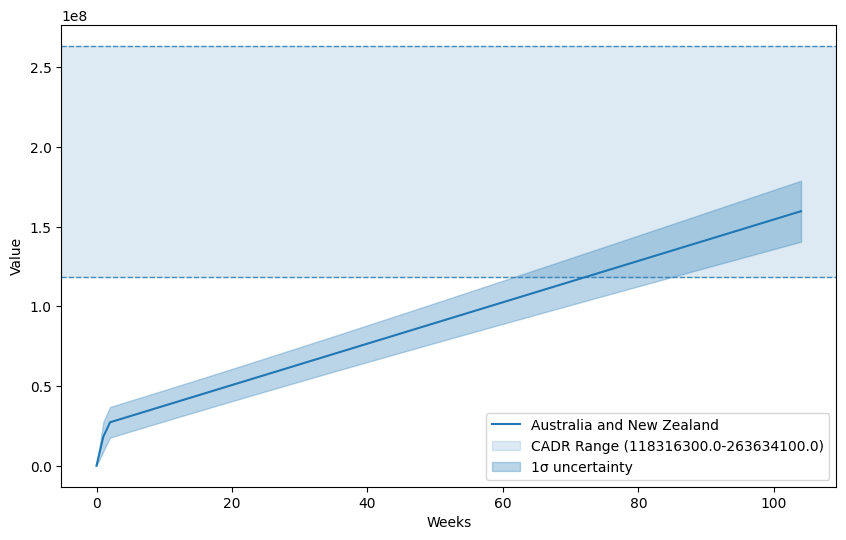

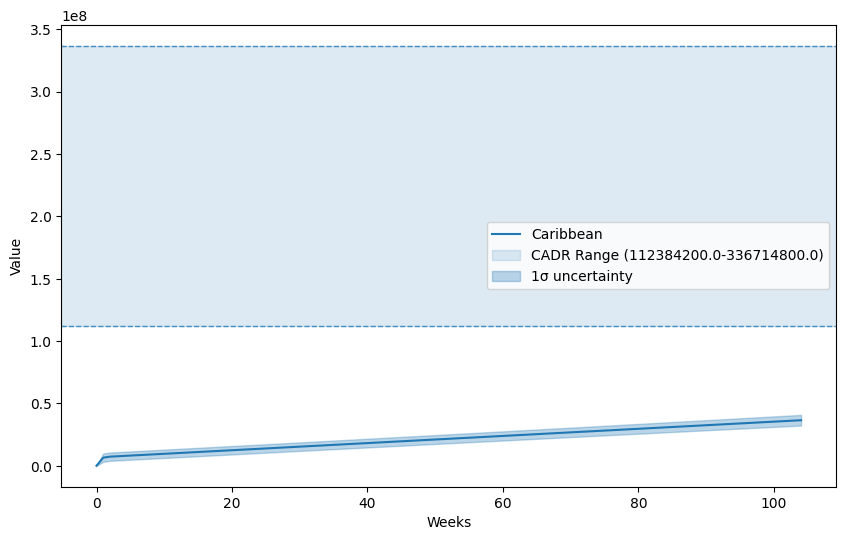

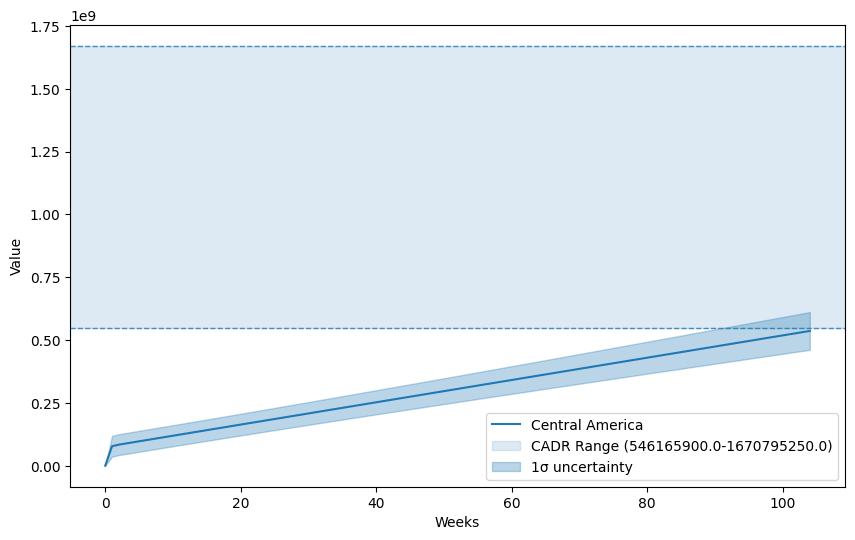

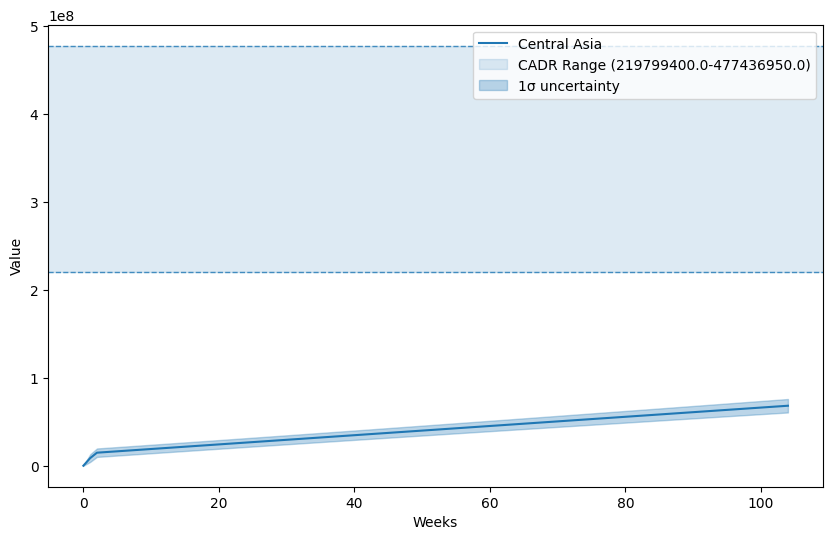

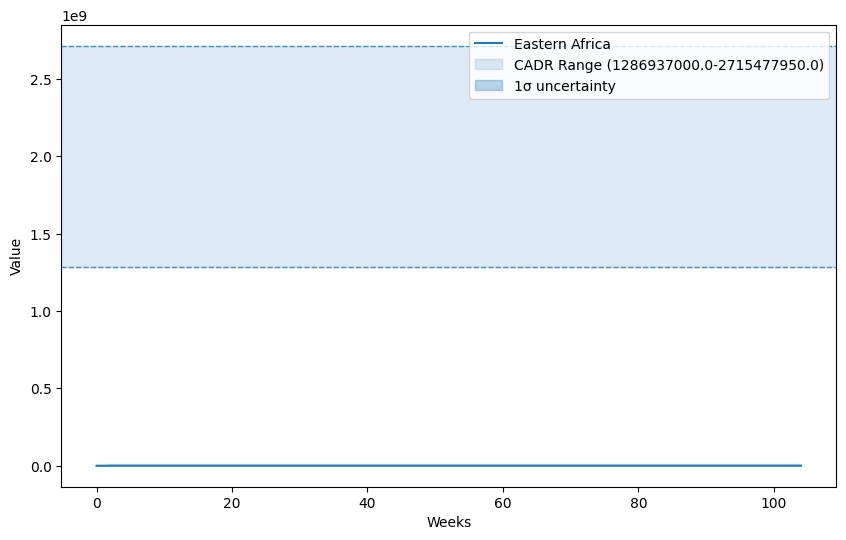

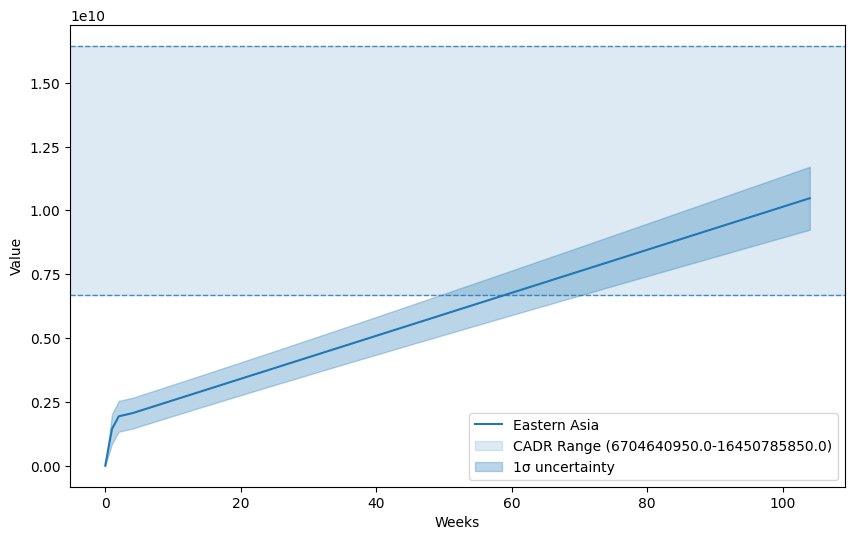

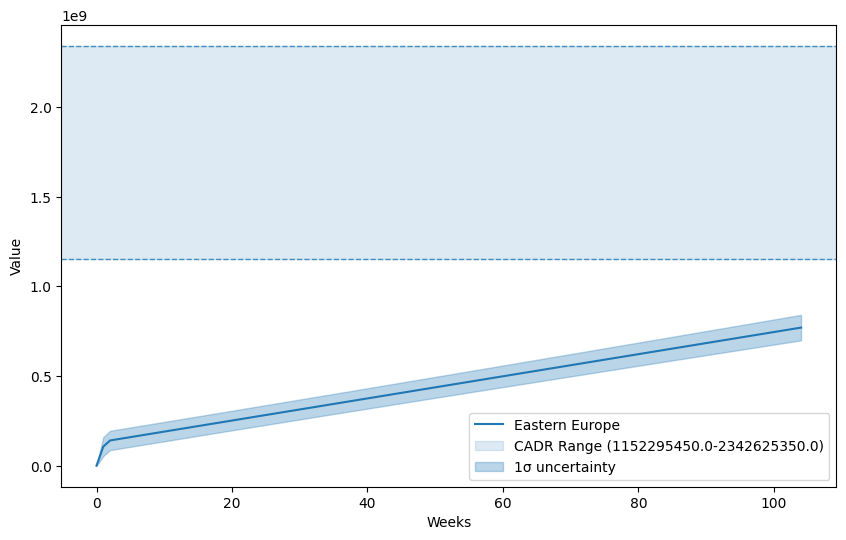

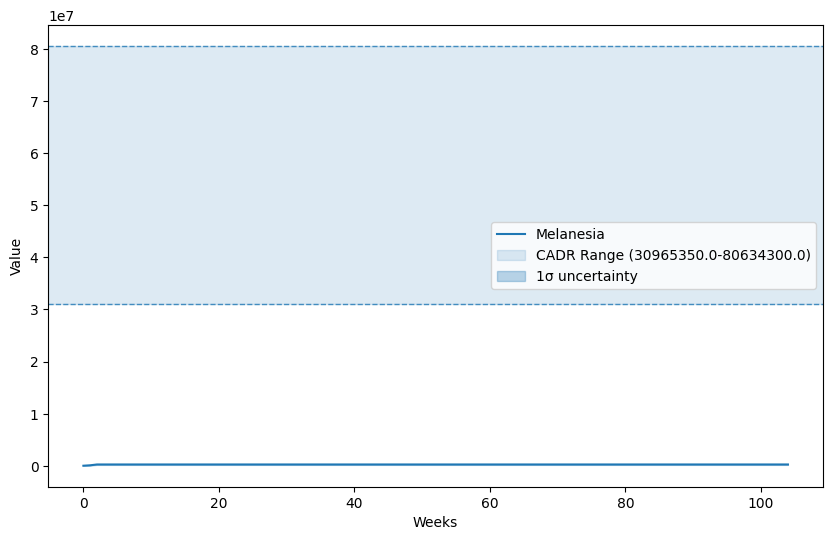

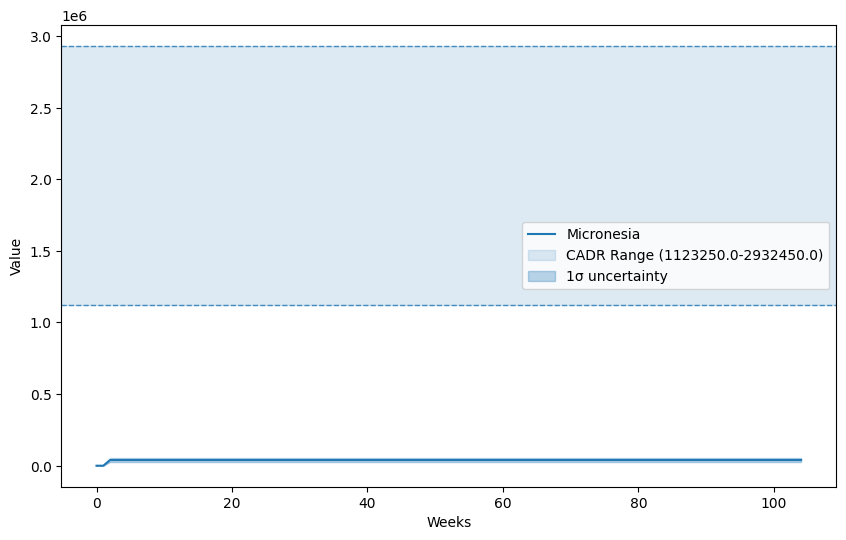

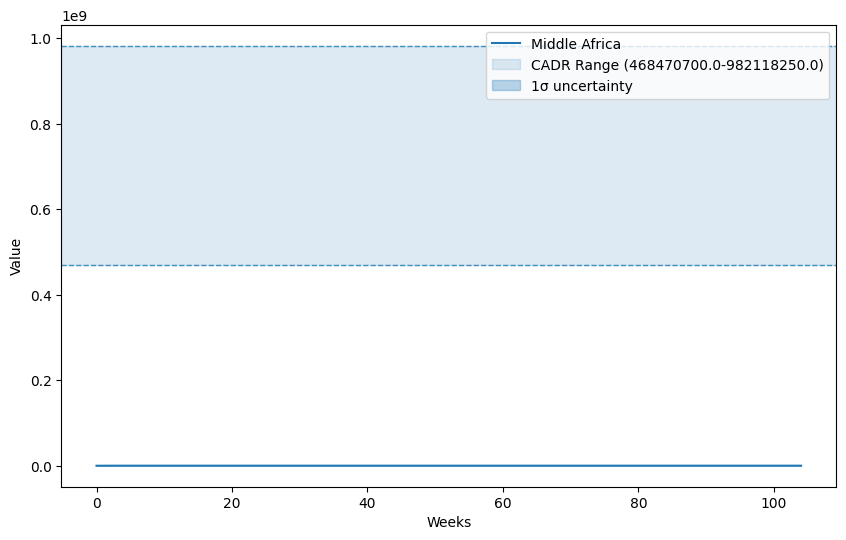

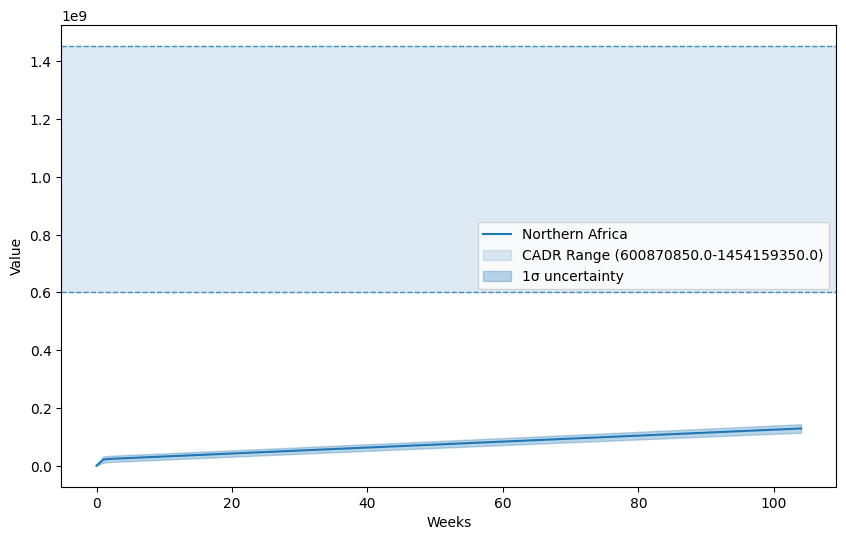

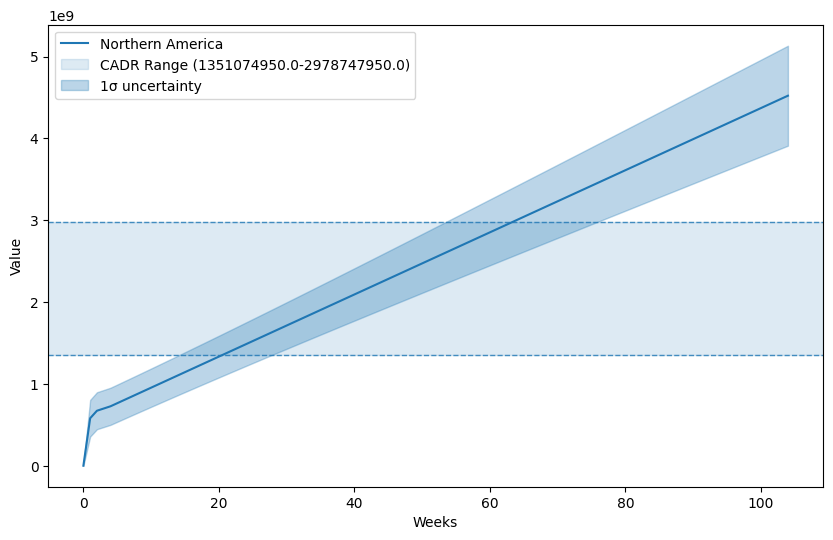

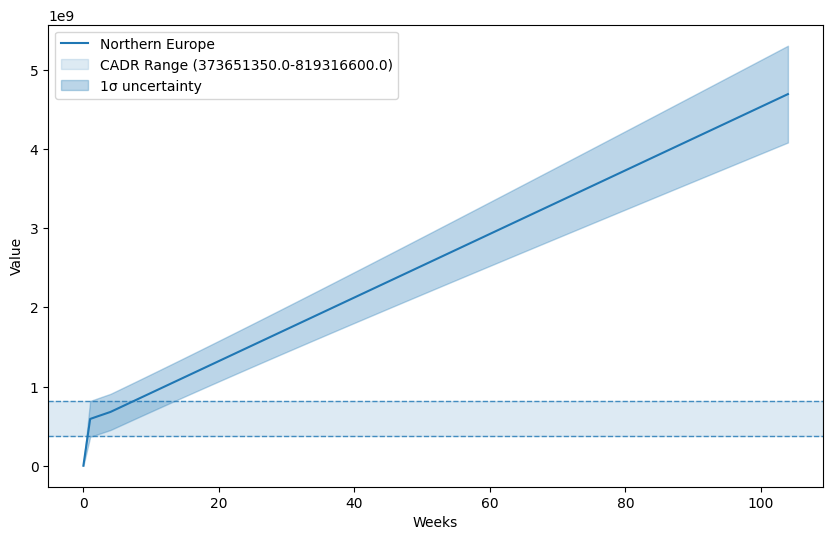

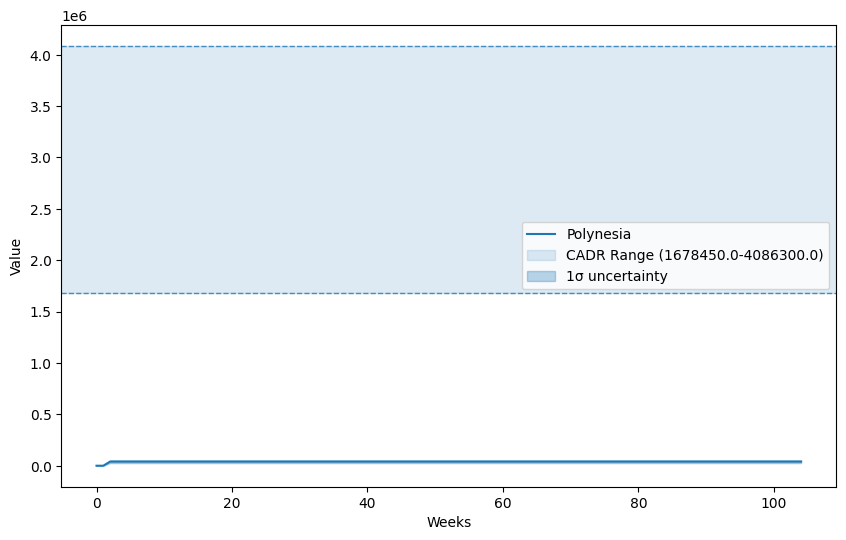

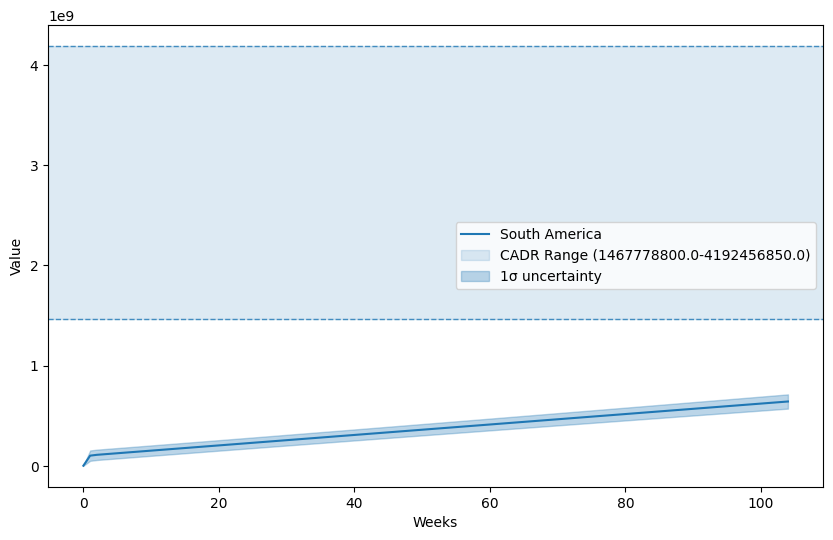

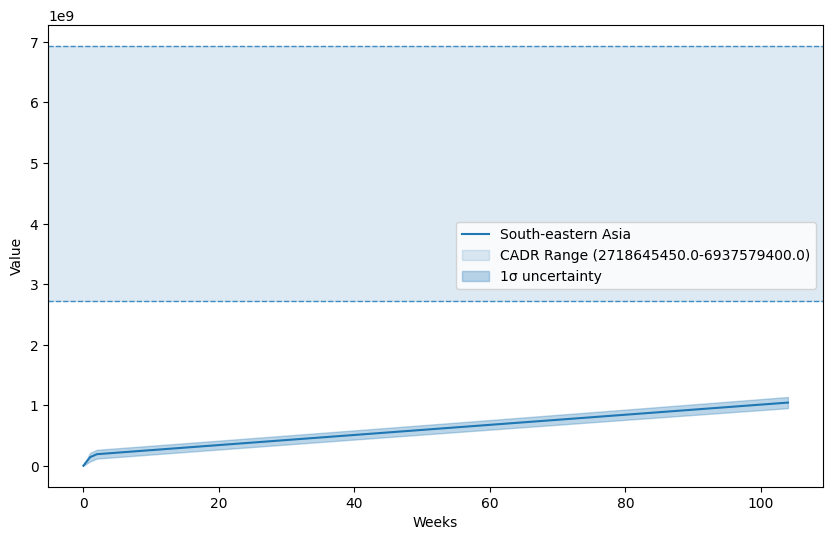

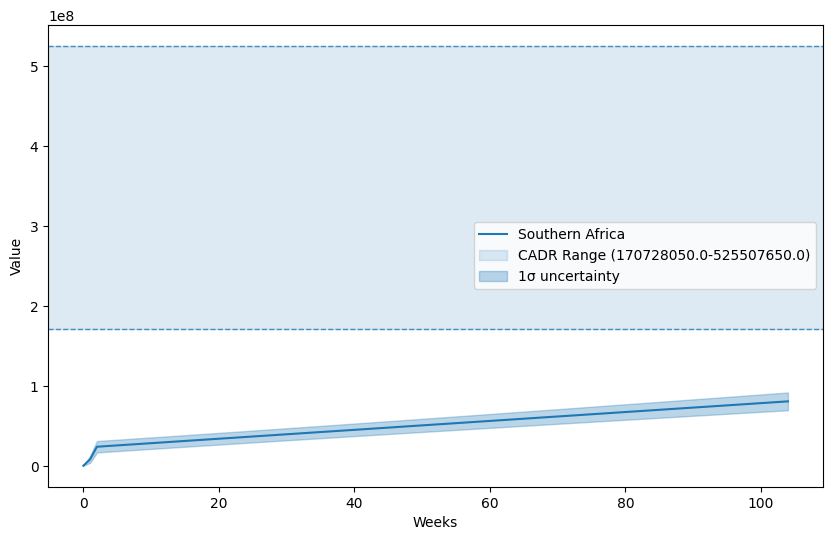

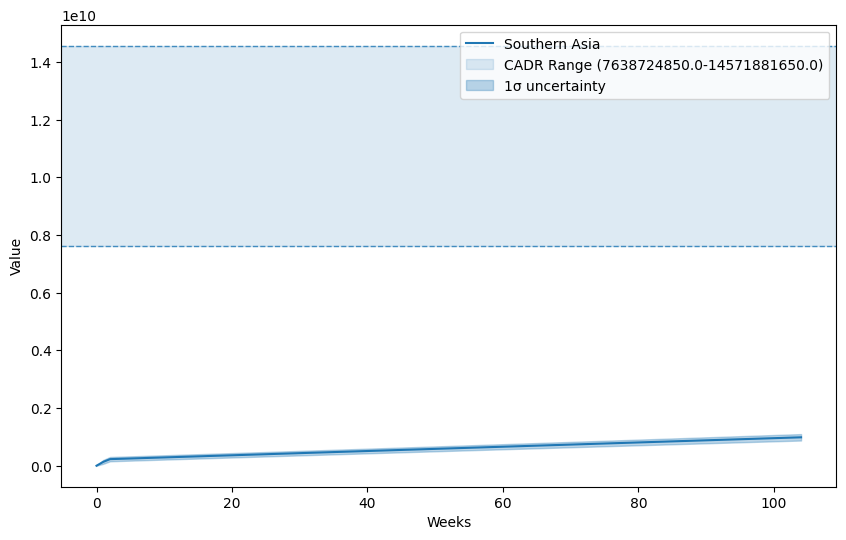

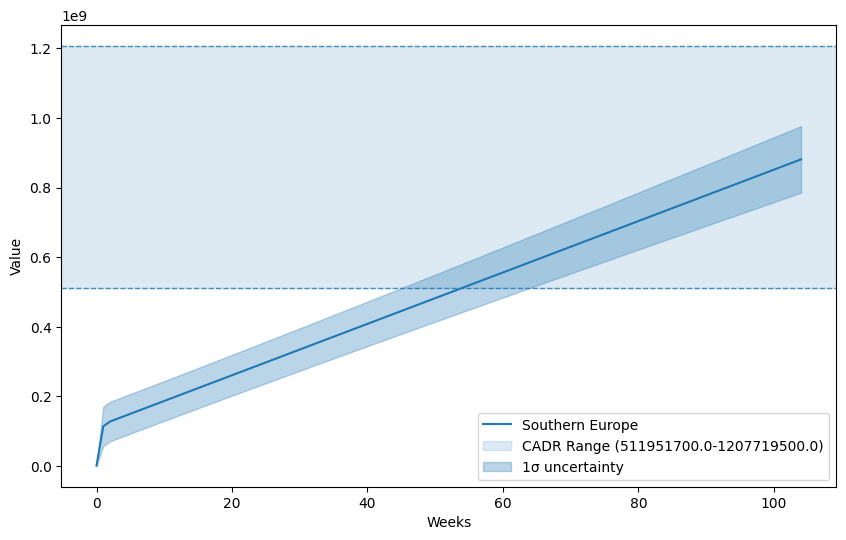

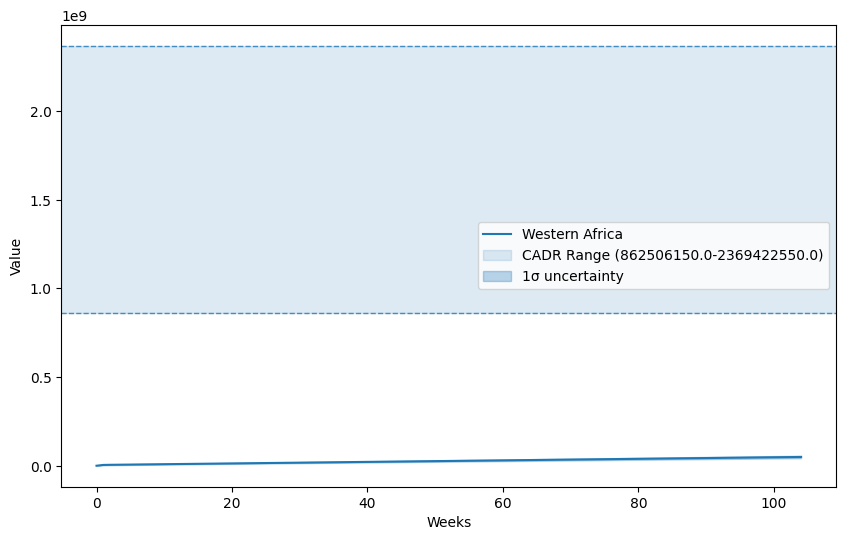

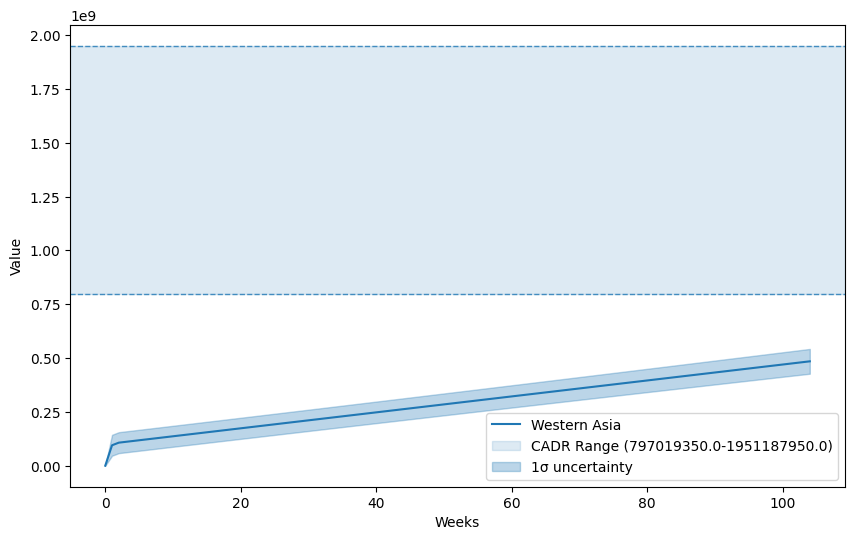

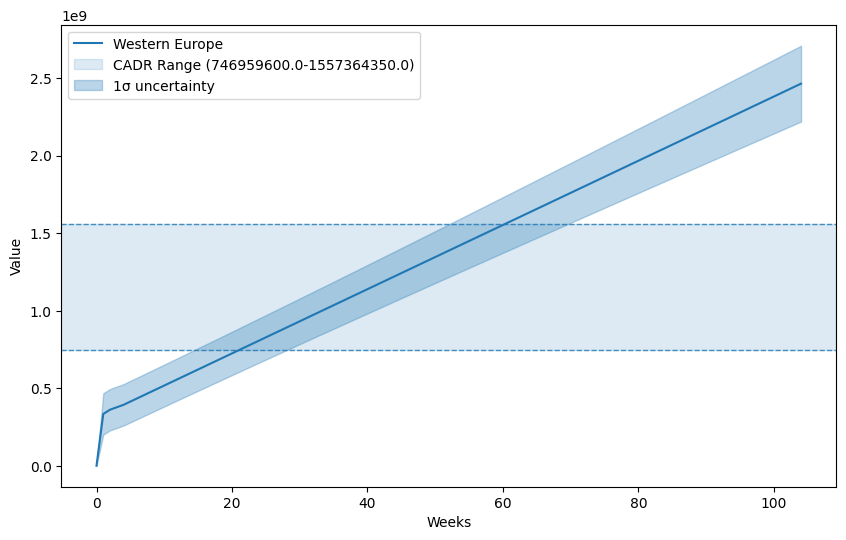

In [167]:
## ---------------------------- Scale Up Plotting for Tester ---------------------------- 

df_loaded = pd.read_pickle(output_path.with_suffix(".pkl"))

region_df = aggregate_by_region(df_loaded, region_type="UNregion")

#print(region_df)

Region_list = region_df['Region'].tolist()

#plot_country(df_loaded, "China", sigma=2)
#plot_multiple_countries(df_loaded, ["China", "India", "Japan"], sigma=2)

# Region-level plots


CADRPP = 50 # L/s


df_ecw = pd.read_csv(ecw_region)

for i in Region_list:
    plot_region(region_df, df_ecw, i, length=None, CADRPP=CADRPP, ax=None, sigma=1)


#plot_multiple_regions(region_df, df_ecw, ['Australia and New Zealand'], CADRPP=CADRPP)

In [41]:
Region_list

['Australia and New Zealand',
 'Caribbean',
 'Central America',
 'Central Asia',
 'Eastern Africa',
 'Eastern Asia',
 'Eastern Europe',
 'Melanesia',
 'Micronesia',
 'Middle Africa',
 'Northern Africa',
 'Northern America',
 'Northern Europe',
 'Polynesia',
 'South America',
 'South-eastern Asia',
 'Southern Africa',
 'Southern Asia',
 'Southern Europe',
 'Western Africa',
 'Western Asia',
 'Western Europe']